# So sánh detector: YOLO-World-L · YOLO26-L · YOLOE-26-L

Cùng pipeline AutoLabel 2D (QA Agent, lan truyền), chỉ đổi detector. Dữ liệu: **2 scene nuScenes v1.0-trainval chọn
ngẫu nhiên** (scene-0031, scene-0065, seed 20260927), mỗi scene 20 keyframe CAM_FRONT, so với GT của nuScenes. Không
model nào được train trên nuScenes (zero-shot).

| Detector | Loại | Prompt / lớp dùng trong lần chạy này |
|---|---|---|
| YOLO-World-L (`yolov8l-worldv2.pt`) | open-vocab | **bộ lớp COCO có sẵn trong model** — máy chạy test không tải được CLIP để đặt prompt theo config |
| YOLO26-L (`yolo26l.pt`) | tập lớp đóng COCO 80 | chỉ giữ lớp trùng tên prompt: car, truck, bus, person, bicycle, motorcycle |
| YOLOE-26-L (`yoloe-26l-seg.pt`) | open-vocab | **đủ 18 prompt của `configs/autolabel.yaml`** (text encoder MobileCLIP2) |

Vì YOLO-World chạy bằng bộ lớp COCO, so sánh công bằng nhất giữa ba model là **mAP trên 5 lớp có trong COCO**
(car, truck, bus, pedestrian, motorcycle). Lớp barrier / traffic cone chỉ YOLOE có prompt.

Chạy lại trên máy có GPU + internet (YOLO-World sẽ dùng đủ prompt): xem ô cuối.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

RESULTS = Path("results/compare") if Path("results/compare").exists() else Path("eval/results/compare")

# Thứ tự và màu cố định theo detector (không đổi theo thứ hạng)
ORDER = ["yolo_world", "yolo_world_full", "yolo26", "yoloe"]
LABEL = {
    "yolo_world": "YOLO-World-L (từ vựng COCO)",
    "yolo_world_full": "YOLO-World-L (đủ prompt)",
    "yolo26": "YOLO26-L (tập lớp đóng)",
    "yoloe": "YOLOE-26-L (đủ prompt)",
}
COLOR = {"yolo_world": "#2a78d6", "yolo_world_full": "#4a3aa7", "yolo26": "#eb6834", "yoloe": "#1baf7a"}
COMMON = ["car", "truck", "bus", "pedestrian", "motorcycle"]  # lớp có trong COCO

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 11, "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": "#9a9994", "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e", "ytick.color": "#52514e", "axes.grid": True, "grid.color": "#e7e6e2", "grid.linewidth": 0.8,
    "axes.axisbelow": True, "legend.frameon": False, "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
})

runs = {}
for name in ORDER:
    d = RESULTS / name
    if (d / "autolabel2d_eval.json").exists():
        runs[name] = {
            "eval": json.loads((d / "autolabel2d_eval.json").read_text()),
            "prop": json.loads((d / "propagation_eval.json").read_text()),
        }
speed = json.loads((RESULTS / "speed.json").read_text()) if (RESULTS / "speed.json").exists() else {"detectors": {}}
print("Có kết quả:", ", ".join(LABEL[n] for n in runs))

Có kết quả: YOLO-World-L (từ vựng COCO), YOLO26-L (tập lớp đóng), YOLOE-26-L (đủ prompt)


## Bảng tổng hợp

In [2]:
def common_map(ev):
    pc = ev["map50"]["per_class"]
    aps = [pc[c]["ap"] for c in COMMON if c in pc and pc[c]["n_gt"] > 0]
    return sum(aps) / len(aps)

def prop_summary(p):
    hops = [h for h in p["per_hop"] if h["tracks_output"]]
    out = sum(h["tracks_output"] for h in hops)
    ok = sum(h["correct"] for h in hops)
    return ok, out, sum(h["id_switch"] for h in hops), p["calibration"]

rows = []
for n, r in runs.items():
    ev, qa = r["eval"], r["eval"]["qa"]
    ok, out, sw, cal = prop_summary(r["prop"])
    sp = speed["detectors"].get(n, {})
    rows.append({
        "Detector": LABEL[n],
        "mAP@0.5 (mọi lớp có GT)": ev["map50"]["map"],
        "mAP@0.5 (5 lớp COCO)": common_map(ev),
        "mAP@0.7": ev["map70"]["map"],
        "Flag recall": qa["flag_recall"],
        "Flag precision": qa["flag_precision"],
        "Lỗi lọt nhóm low": qa["low_risk_error_rate"],
        "Object máy sinh": qa["objects_evaluated"],
        "Lan truyền đúng": f"{ok}/{out}",
        "Đổi ID": sw,
        "Giây/ảnh (CPU)": sp.get("mean_s"),
    })
summary = pd.DataFrame(rows).set_index("Detector")
summary.style.format({c: "{:.3f}" for c in summary.columns if summary[c].dtype == float})

,mAP@0.5 (mọi lớp có GT),mAP@0.5 (5 lớp COCO),mAP@0.7,Flag recall,Flag precision,Lỗi lọt nhóm low,Object máy sinh,Lan truyền đúng,Đổi ID,Giây/ảnh (CPU)
Detector,,,,,,,,,,
YOLO-World-L (từ vựng COCO),0.311,0.374,0.208,0.783,0.792,0.356,310,38/41,0,3.750
YOLO26-L (tập lớp đóng),0.398,0.477,0.265,0.605,0.894,0.570,496,36/41,0,2.137
YOLOE-26-L (đủ prompt),0.452,0.452,0.278,0.764,0.858,0.383,440,50/52,0,3.309


## AP@0.5 theo lớp

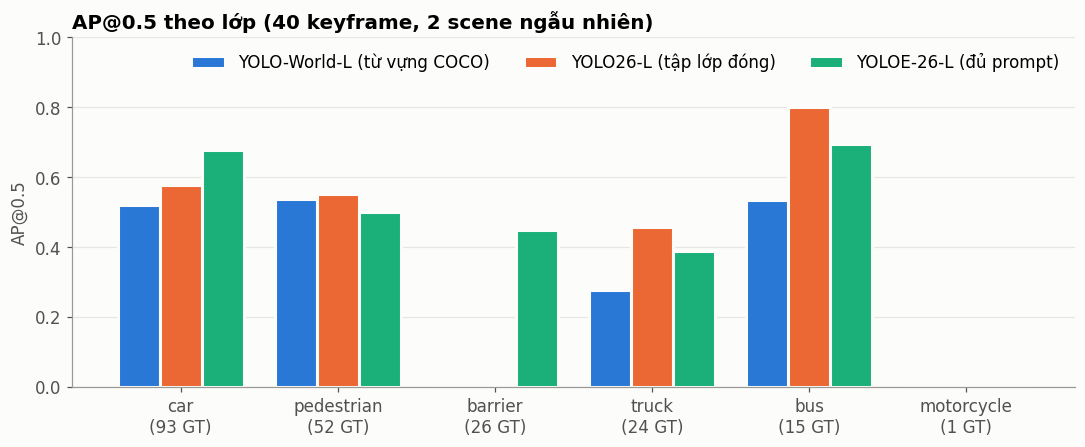

In [3]:
classes = sorted({c for r in runs.values() for c, v in r["eval"]["map50"]["per_class"].items() if v["n_gt"] > 0},
                 key=lambda c: -max(r["eval"]["map50"]["per_class"].get(c, {"n_gt": 0})["n_gt"] for r in runs.values()))
n_gt = {c: max(r["eval"]["map50"]["per_class"].get(c, {"n_gt": 0})["n_gt"] for r in runs.values()) for c in classes}
names = list(runs)
w = 0.8 / len(names)
fig, ax = plt.subplots(figsize=(10, 4.2))
for i, n in enumerate(names):
    pc = runs[n]["eval"]["map50"]["per_class"]
    xs = [k + (i - (len(names) - 1) / 2) * w for k in range(len(classes))]
    ax.bar(xs, [pc.get(c, {"ap": 0})["ap"] for c in classes], width=w, color=COLOR[n], label=LABEL[n],
           edgecolor="#fcfcfb", linewidth=2)
ax.set_xticks(range(len(classes)), [f"{c}\n({n_gt[c]} GT)" for c in classes])
ax.set_ylim(0, 1)
ax.set_ylabel("AP@0.5")
ax.set_title("AP@0.5 theo lớp (40 keyframe, 2 scene ngẫu nhiên)")
ax.grid(axis="x", visible=False)
ax.legend(loc="upper right", ncols=len(names))
plt.tight_layout()
plt.show()

## QA Agent: cờ có đúng chỗ không

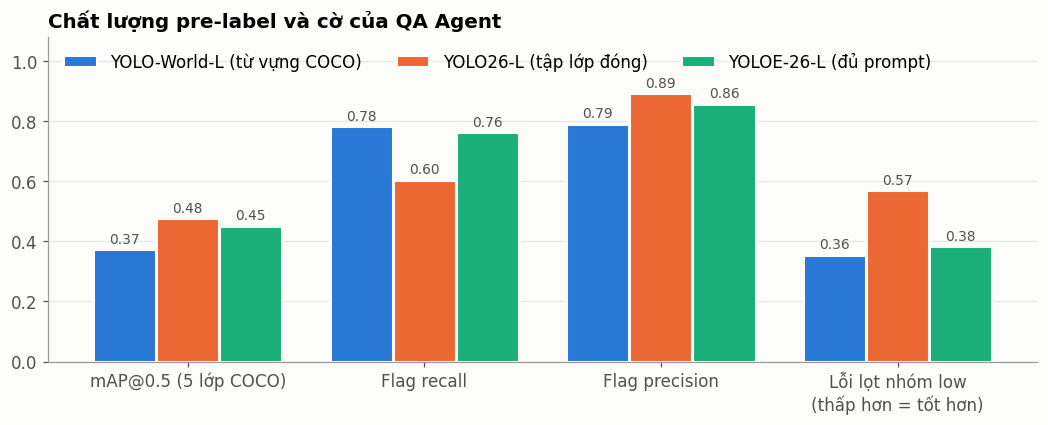

In [4]:
metrics = [("mAP@0.5 (5 lớp COCO)", None), ("Flag recall", "flag_recall"), ("Flag precision", "flag_precision"),
           ("Lỗi lọt nhóm low\n(thấp hơn = tốt hơn)", "low_risk_error_rate")]
fig, ax = plt.subplots(figsize=(10, 4))
for i, n in enumerate(names):
    qa = runs[n]["eval"]["qa"]
    vals = [common_map(runs[n]["eval"]) if key is None else qa[key] for _, key in metrics]
    xs = [k + (i - (len(names) - 1) / 2) * w for k in range(len(metrics))]
    bars = ax.bar(xs, vals, width=w, color=COLOR[n], label=LABEL[n], edgecolor="#fcfcfb", linewidth=2)
    ax.bar_label(bars, fmt="%.2f", padding=2, fontsize=9, color="#52514e")
ax.set_xticks(range(len(metrics)), [m for m, _ in metrics])
ax.set_ylim(0, 1.08)
ax.set_title("Chất lượng pre-label và cờ của QA Agent")
ax.grid(axis="x", visible=False)
ax.legend(loc="upper left", ncols=len(names))
plt.tight_layout()
plt.show()

## Lan truyền nhãn (thí nghiệm keyframe hoàn hảo)

GT ở keyframe đầu mỗi scene đóng vai nhãn người đã duyệt; tracker dùng detection của từng detector qua mọi ảnh 12 Hz.
**Độ phủ** = trong số object của keyframe đầu còn xuất hiện ở frame đó, bao nhiêu % còn được track. **Tỉ lệ đúng** =
trong số nhãn lan truyền ra, bao nhiêu % khớp GT cùng `instance_token` (IoU ≥ 0.5).

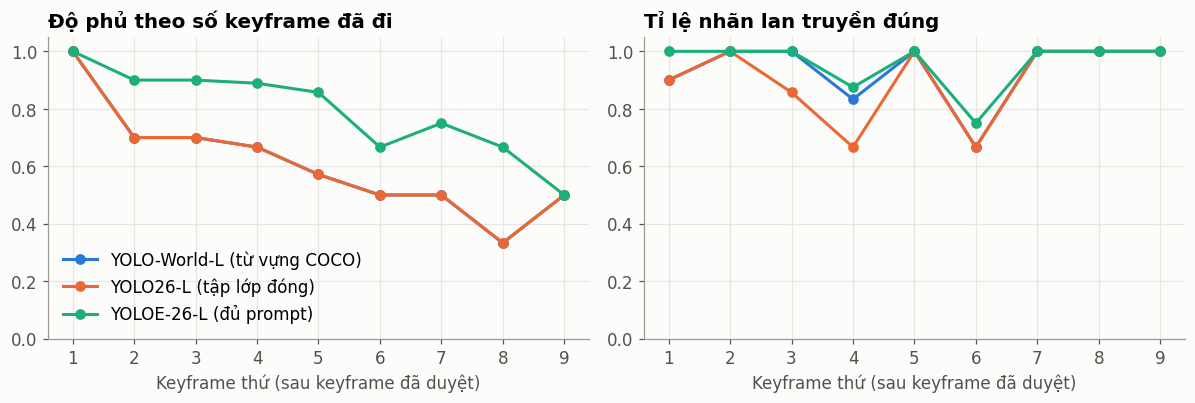

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharex=True)
for n in names:
    hops = [h for h in runs[n]["prop"]["per_hop"] if h["coverage"] is not None]
    axes[0].plot([h["hop"] for h in hops], [h["coverage"] for h in hops], marker="o", ms=6, lw=2, color=COLOR[n], label=LABEL[n])
    hc = [h for h in hops if h["correct_rate"] is not None]
    axes[1].plot([h["hop"] for h in hc], [h["correct_rate"] for h in hc], marker="o", ms=6, lw=2, color=COLOR[n], label=LABEL[n])
axes[0].set_title("Độ phủ theo số keyframe đã đi")
axes[1].set_title("Tỉ lệ nhãn lan truyền đúng")
for a in axes:
    a.set_ylim(0, 1.05)
    a.set_xlabel("Keyframe thứ (sau keyframe đã duyệt)")
axes[0].legend(loc="lower left")
plt.tight_layout()
plt.show()

## Tốc độ

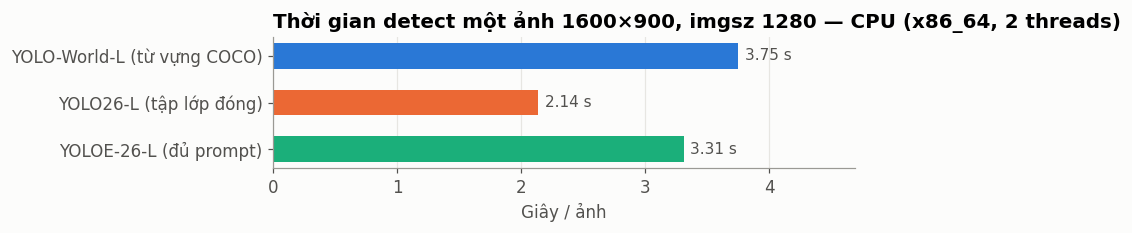

In [6]:
if speed["detectors"]:
    sn = [n for n in names if n in speed["detectors"]]
    fig, ax = plt.subplots(figsize=(8, 0.6 + 0.55 * len(sn)))
    vals = [speed["detectors"][n]["mean_s"] for n in sn]
    bars = ax.barh([LABEL[n] for n in sn], vals, color=[COLOR[n] for n in sn], height=0.55)
    ax.bar_label(bars, labels=[f"{v:.2f} s" for v in vals], padding=4, fontsize=10, color="#52514e")
    ax.invert_yaxis()
    ax.set_xlabel("Giây / ảnh")
    ax.set_title(f"Thời gian detect một ảnh 1600×900, imgsz 1280 — {speed['device']}")
    ax.grid(axis="y", visible=False)
    ax.set_xlim(0, max(vals) * 1.25)
    plt.tight_layout()
    plt.show()

## Kết luận (lần chạy 2026-09-28)

**YOLOE-26-L tốt nhất tổng thể và là ứng viên thay YOLO-World làm detector mặc định.**

- **Chất lượng box:** mAP@0.5 0.45, so với 0.40 (YOLO26) và 0.31 (YOLO-World). YOLOE là model duy nhất nhận được barrier (AP 0.45 trên 26 GT) và có AP car cao nhất (0.68). Số GT không có box nào khớp cũng ít nhất: 45, so với 61–65 của hai model kia.
- **Lan truyền:** 50/52 nhãn đúng, không đổi ID. Độ phủ còn ≥ 0.86 tới keyframe thứ 5, hai model kia chỉ còn 0.57 (đường YOLO-World và YOLO26 trùng nhau trên biểu đồ độ phủ). YOLOE bám được thêm các rào chắn mà hai model COCO không thấy.
- **YOLO26-L:** nhanh nhất (2.1 s/ảnh trên CPU, 3.3 s với YOLOE, 3.75 s với YOLO-World) và mạnh nhất ở bus/truck, nên mAP trên 5 lớp COCO cao nhất (0.48). Nhưng nó sinh nhiều box hơn (496 object, 362 cần sửa) và QA để lọt 57% lỗi vào nhóm low, nên duyệt theo lô rủi ro. Nó cũng không nhận được barrier, traffic cone. Hợp làm model phụ trong ensemble hơn là detector chính.
- **YOLO-World-L bị thiệt** vì máy test chỉ chạy được bằng bộ lớp COCO. Cần chạy lại với đủ prompt trên GPU (ô "Chạy lại") trước khi loại hẳn.
- **Giới hạn:** mẫu nhỏ (40 keyframe, 2 scene), chênh lệch vài điểm AP chưa chắc chắn. Motorcycle chỉ có 1 GT nên AP bằng 0 với cả ba model.


## Chạy lại

Trên máy có GPU và internet (YOLO-World tải được CLIP nên dùng đủ prompt), từ thư mục repo, với `.env` trỏ tới
dữ liệu (xem README). Mỗi detector một workspace riêng:

```powershell
foreach ($d in "yolo_world","yolo26","yoloe") {
  $env:WORKSPACE_DIR = "data/compare/$d"
  python -m src.cli run --scenes scene-0031 scene-0065 --detectors $d
  python -m src.cli detect-sweeps --scenes scene-0031 scene-0065 --detectors $d
  python -m src.cli evaluate --out eval/results/compare/$d
  python -m src.cli eval-propagation --detectors $d --out eval/results/compare/$d
}
python scripts/bench_detectors.py --detectors yolo_world yolo26 yoloe --out eval/results/compare/speed.json
```

Muốn giữ kết quả YOLO-World từ vựng COCO để so, ghi YOLO-World đủ prompt vào `eval/results/compare/yolo_world_full`
(notebook tự nhận thêm đường đó).